# 🔐 Sentinel AI — Entrenamiento con Dataset Real NSL-KDD

**Dataset:** NSL-KDD (KDDTrain+.arff / KDDTest+.arff)  
**Algoritmo:** Isolation Forest (no supervisado)  
**Autor:** [Tu nombre]  
**Curso:** Inteligencia Artificial Aplicada — 2026

---

## ¿Por qué NSL-KDD?

NSL-KDD es el dataset estándar de la industria para evaluar sistemas de detección de intrusiones.
Contiene tráfico de red real capturado en un entorno controlado, incluyendo ataques reales como:
- **DoS** (Denial of Service): saturar el servidor con peticiones
- **Probe**: escaneo de puertos y reconocimiento
- **R2L** (Remote to Local): acceso no autorizado remoto
- **U2R** (User to Root): escalada de privilegios

A diferencia de los datos sintéticos, este dataset tiene comportamientos de red REALES,
lo que hace el modelo mucho más confiable y representativo.


In [25]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib

Note: you may need to restart the kernel to use updated packages.


In [26]:
# ── Importaciones ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.io import arff
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('dark_background')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar el dataset NSL-KDD

El archivo `.arff` es el formato de Weka. Usamos `scipy.io.arff` para leerlo y convertirlo a DataFrame.

In [27]:
# ── Cargar archivo .arff manualmente (evita bug de formato del NSL-KDD) ──────
TRAIN_PATH = '../data/KDDTrain+.arff'

# Leer líneas del archivo
with open(TRAIN_PATH, 'r') as f:
    lines = f.readlines()

# Separar encabezado (@attribute) de los datos (@data)
col_names = []
data_lines = []
in_data = False

for line in lines:
    line = line.strip()
    if line.lower().startswith('@attribute'):
        # Extraer nombre de columna (segunda palabra)
        col_name = line.split()[1].replace("'", "")
        col_names.append(col_name)
    elif line.lower().startswith('@data'):
        in_data = True
    elif in_data and line and not line.startswith('%'):
        data_lines.append(line)

# Convertir a DataFrame
from io import StringIO
csv_content = '\n'.join(data_lines)
df = pd.read_csv(StringIO(csv_content), header=None, names=col_names)

print(f'✅ Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} columnas')
print(f'\nDistribución de clases:')
print(df['class'].value_counts())
df.head()

✅ Dataset cargado: 125,973 registros, 42 columnas

Distribución de clases:
class
normal     67343
anomaly    58630
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 2. Selección de Features

El dataset tiene 41 columnas. Seleccionamos las **8 más relevantes** para detección de comportamiento anómalo.
Estas features son las que tienen más poder explicativo y son fáciles de interpretar:

| Feature | Descripción | Por qué importa |
|---------|-------------|------------------|
| `duration` | Duración de la conexión en segundos | Conexiones muy largas o muy cortas son sospechosas |
| `protocol_type` | Protocolo de red (tcp, udp, icmp) | Ciertos ataques usan protocolos específicos |
| `service` | Servicio de destino (http, ftp, ssh...) | Accesos a servicios inusuales = sospechoso |
| `flag` | Estado de la conexión (SF, REJ, S0...) | REJ/S0 indican conexiones rechazadas o incompletas |
| `src_bytes` | Bytes enviados por el origen | Transferencias masivas = posible exfiltración |
| `num_failed_logins` | Intentos fallidos de login | Ataques de fuerza bruta dejan esta huella |
| `count` | Conexiones al mismo host (últimos 2 seg) | Muchas conexiones rápidas = posible DoS |
| `logged_in` | Si el usuario inició sesión exitosamente | Diferenciar intentos fallidos de accesos reales |

In [28]:
# ── Seleccionar las 8 features más relevantes ────────────────────────────────
FEATURES = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'num_failed_logins',
    'count',
    'logged_in'
]

# Guardar las etiquetas reales para validación posterior
# (NO se usan para entrenar — el modelo es no supervisado)
y_true = df['class'].map({'normal': 1, 'anomaly': -1})

df_model = df[FEATURES].copy()

print('Features seleccionadas:')
print(df_model.dtypes)
print(f'\nValores nulos: {df_model.isnull().sum().sum()}')
df_model.head()

Features seleccionadas:
duration             int64
protocol_type          str
service                str
flag                   str
src_bytes            int64
num_failed_logins    int64
count                int64
logged_in            int64
dtype: object

Valores nulos: 0


,duration,protocol_type,service,flag,src_bytes,num_failed_logins,count,logged_in
0,0,tcp,ftp_data,SF,491,0,2,0
1,0,udp,other,SF,146,0,13,0
2,0,tcp,private,S0,0,0,123,0
3,0,tcp,http,SF,232,0,5,1
4,0,tcp,http,SF,199,0,30,1


## 3. Preprocesamiento — LabelEncoder

Las columnas `protocol_type`, `service`, `flag` y `logged_in` son categóricas.
Las convertimos a números con LabelEncoder para que el modelo pueda procesarlas.

**Importante:** documentamos cada mapeo exactamente como se usará en la app.

In [29]:
# ── Encoding de variables categóricas ───────────────────────────────────────
le = LabelEncoder()
categorical_cols = ['protocol_type', 'service', 'flag', 'logged_in']

encoders = {}  # Guardamos cada encoder para usarlo en la app

for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
    encoders[col] = mapping
    print(f'{col}: {mapping}')

# Convertir numéricas a float por si acaso
numeric_cols = ['duration', 'src_bytes', 'num_failed_logins', 'count']
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)

print('\n✅ Encoding completado')
print(f'Shape final: {df_model.shape}')
df_model.head()

protocol_type: {'icmp': 0, 'tcp': 1, 'udp': 2}
service: {'IRC': 0, 'X11': 1, 'Z39_50': 2, 'aol': 3, 'auth': 4, 'bgp': 5, 'courier': 6, 'csnet_ns': 7, 'ctf': 8, 'daytime': 9, 'discard': 10, 'domain': 11, 'domain_u': 12, 'echo': 13, 'eco_i': 14, 'ecr_i': 15, 'efs': 16, 'exec': 17, 'finger': 18, 'ftp': 19, 'ftp_data': 20, 'gopher': 21, 'harvest': 22, 'hostnames': 23, 'http': 24, 'http_2784': 25, 'http_443': 26, 'http_8001': 27, 'imap4': 28, 'iso_tsap': 29, 'klogin': 30, 'kshell': 31, 'ldap': 32, 'link': 33, 'login': 34, 'mtp': 35, 'name': 36, 'netbios_dgm': 37, 'netbios_ns': 38, 'netbios_ssn': 39, 'netstat': 40, 'nnsp': 41, 'nntp': 42, 'ntp_u': 43, 'other': 44, 'pm_dump': 45, 'pop_2': 46, 'pop_3': 47, 'printer': 48, 'private': 49, 'red_i': 50, 'remote_job': 51, 'rje': 52, 'shell': 53, 'smtp': 54, 'sql_net': 55, 'ssh': 56, 'sunrpc': 57, 'supdup': 58, 'systat': 59, 'telnet': 60, 'tftp_u': 61, 'tim_i': 62, 'time': 63, 'urh_i': 64, 'urp_i': 65, 'uucp': 66, 'uucp_path': 67, 'vmnet': 68, 'whois

,duration,protocol_type,service,flag,src_bytes,num_failed_logins,count,logged_in
0,0,1,20,9,491,0,2,0
1,0,2,44,9,146,0,13,0
2,0,1,49,5,0,0,123,0
3,0,1,24,9,232,0,5,1
4,0,1,24,9,199,0,30,1


In [30]:
# ── Estadísticas descriptivas de las features numéricas ─────────────────────
print('=== ESTADÍSTICAS DEL DATASET ===')
print(df_model[numeric_cols].describe().round(2))

print('\n=== DISTRIBUCIÓN DE CLASES REALES ===')
print(y_true.value_counts())
print(f'Porcentaje de anomalías: {(y_true == -1).mean()*100:.1f}%')

=== ESTADÍSTICAS DEL DATASET ===
        duration     src_bytes  num_failed_logins      count
count  125973.00  1.259730e+05          125973.00  125973.00
mean      287.14  4.556674e+04               0.00      84.11
std      2604.52  5.870331e+06               0.05     114.51
min         0.00  0.000000e+00               0.00       0.00
25%         0.00  0.000000e+00               0.00       2.00
50%         0.00  4.400000e+01               0.00      14.00
75%         0.00  2.760000e+02               0.00     143.00
max     42908.00  1.379964e+09               5.00     511.00

=== DISTRIBUCIÓN DE CLASES REALES ===
class
 1    67343
-1    58630
Name: count, dtype: int64
Porcentaje de anomalías: 46.5%


## 4. Entrenamiento del Modelo

Entrenamos Isolation Forest de forma **no supervisada** — el modelo NO ve las etiquetas reales.
Aprende qué es normal por sí solo. Después comparamos sus predicciones con las etiquetas reales
para evaluar qué tan bien funciona.

El parámetro `contamination` lo ajustamos según el porcentaje real de anomalías en el dataset.

In [31]:
# ── Calcular contamination real del dataset ──────────────────────────────────
real_contamination = round((y_true == -1).mean(), 2)
print(f'Porcentaje real de anomalías en el dataset: {real_contamination*100:.1f}%')
print(f'Se usará contamination = {real_contamination}')

# ── Entrenar Isolation Forest ────────────────────────────────────────────────
model = IsolationForest(
    contamination=real_contamination,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(df_model)

predictions   = model.predict(df_model)       # -1 = anómalo, 1 = normal
anomaly_scores = model.decision_function(df_model)  # Score continuo

df_model['anomaly']       = predictions
df_model['anomaly_score'] = anomaly_scores

print(f'\n=== PREDICCIONES DEL MODELO ===')
print(f'Normales:  {(predictions == 1).sum():,} ({(predictions == 1).mean()*100:.1f}%)')
print(f'Anómalos:  {(predictions == -1).sum():,} ({(predictions == -1).mean()*100:.1f}%)')

Porcentaje real de anomalías en el dataset: 47.0%
Se usará contamination = 0.47

=== PREDICCIONES DEL MODELO ===
Normales:  66,774 (53.0%)
Anómalos:  59,199 (47.0%)


## 5. Evaluación del Modelo

Como tenemos las etiquetas reales del NSL-KDD, podemos evaluar qué tan bien detectó el modelo.
Esto es una ventaja enorme sobre los datos sintéticos — podemos medir precision y recall reales.

In [32]:
# ── Evaluación vs etiquetas reales ───────────────────────────────────────────
print('=== REPORTE DE CLASIFICACIÓN ===')
print('(Comparando predicciones del modelo vs etiquetas reales del dataset)')
print()
print(classification_report(
    y_true,
    predictions,
    target_names=['Anómalo (-1)', 'Normal (1)']
))

# Matriz de confusión
cm = confusion_matrix(y_true, predictions)
print('Matriz de confusión:')
print(f'  Verdaderos Negativos (normal detectado como normal): {cm[1][1]:,}')
print(f'  Falsos Positivos (normal detectado como anómalo):    {cm[1][0]:,}')
print(f'  Falsos Negativos (anómalo NO detectado):             {cm[0][1]:,}')
print(f'  Verdaderos Positivos (anómalo detectado):            {cm[0][0]:,}')

=== REPORTE DE CLASIFICACIÓN ===
(Comparando predicciones del modelo vs etiquetas reales del dataset)

              precision    recall  f1-score   support

Anómalo (-1)       0.55      0.56      0.55     58630
  Normal (1)       0.61      0.61      0.61     67343

    accuracy                           0.58    125973
   macro avg       0.58      0.58      0.58    125973
weighted avg       0.58      0.58      0.58    125973

Matriz de confusión:
  Verdaderos Negativos (normal detectado como normal): 40,840
  Falsos Positivos (normal detectado como anómalo):    26,503
  Falsos Negativos (anómalo NO detectado):             25,934
  Verdaderos Positivos (anómalo detectado):            32,696


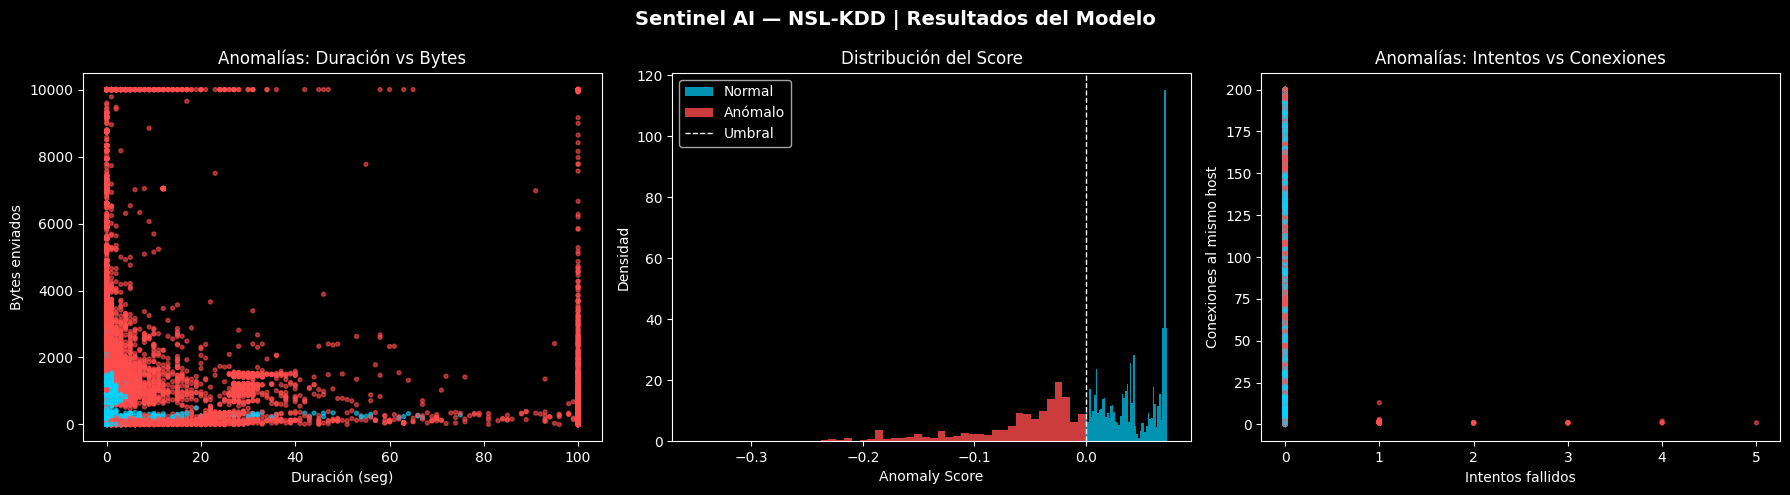

Azul = normal | Rojo = anómalo detectado por el modelo


In [33]:
# ── Visualizaciones ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sentinel AI — NSL-KDD | Resultados del Modelo', fontsize=14, fontweight='bold')

# 1. Scatter: duration vs src_bytes
colors = ['#FF4D4D' if a == -1 else '#00D4FF22' for a in predictions]
axes[0].scatter(df_model['duration'].clip(0, 100),
                df_model['src_bytes'].clip(0, 10000),
                c=colors, s=8, alpha=0.6)
axes[0].set_xlabel('Duración (seg)')
axes[0].set_ylabel('Bytes enviados')
axes[0].set_title('Anomalías: Duración vs Bytes')

# 2. Distribución del anomaly score
axes[1].hist(anomaly_scores[predictions == 1],  bins=50, color='#00D4FF', alpha=0.7, label='Normal', density=True)
axes[1].hist(anomaly_scores[predictions == -1], bins=50, color='#FF4D4D', alpha=0.8, label='Anómalo', density=True)
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=1, label='Umbral')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución del Score')
axes[1].legend()

# 3. Intentos fallidos vs count
axes[2].scatter(df_model['num_failed_logins'].clip(0, 10),
                df_model['count'].clip(0, 200),
                c=colors, s=8, alpha=0.6)
axes[2].set_xlabel('Intentos fallidos')
axes[2].set_ylabel('Conexiones al mismo host')
axes[2].set_title('Anomalías: Intentos vs Conexiones')

plt.tight_layout()
plt.show()
print('Azul = normal | Rojo = anómalo detectado por el modelo')

## 6. Exportar Modelo y Datos

In [34]:
# ── Guardar modelo y datos ───────────────────────────────────────────────────
os.makedirs('../model', exist_ok=True)

# Guardar el modelo
joblib.dump(model, '../model/anomaly_model.pkl')
print('✅ Modelo guardado: model/anomaly_model.pkl')

# Guardar los mapeos de encoding para la app
import json
with open('../model/encoders.json', 'w') as f:
    json.dump(encoders, f, indent=2)
print('✅ Encoders guardados: model/encoders.json')

# Guardar processed_data (sin anomaly_score para la app)
df_to_save = df_model.drop(columns=['anomaly_score'])
df_to_save.to_csv('../data/processed_data.csv', index=False)
print('✅ Datos guardados: data/processed_data.csv')

# ── Verificar que el modelo funciona ────────────────────────────────────────
# Caso normal: conexión tcp corta a http, sin intentos fallidos
test_normal  = [[0, encoders['protocol_type']['tcp'],
                    encoders['service']['http'],
                    encoders['flag']['SF'],
                    234, 0, 4, encoders['logged_in']['1']]]

# Caso anómalo: muchas conexiones rápidas, sin login
test_anomaly = [[0, encoders['protocol_type']['icmp'],
                    encoders['service'].get('eco_i', 0),
                    encoders['flag']['S0'],
                    0, 5, 500, encoders['logged_in']['0']]]

pred_n = model.predict(test_normal)[0]
pred_a = model.predict(test_anomaly)[0]
score_n = model.decision_function(test_normal)[0]
score_a = model.decision_function(test_anomaly)[0]

print(f'\n=== VERIFICACIÓN ===')
print(f'Caso normal  → {"Normal ✅" if pred_n == 1 else "Anómalo ⚠️"}  | Score: {score_n:.4f}')
print(f'Caso anómalo → {"Anómalo ✅" if pred_a == -1 else "Normal ⚠️"}  | Score: {score_a:.4f}')

✅ Modelo guardado: model/anomaly_model.pkl
✅ Encoders guardados: model/encoders.json
✅ Datos guardados: data/processed_data.csv

=== VERIFICACIÓN ===
Caso normal  → Normal ✅  | Score: 0.0705
Caso anómalo → Anómalo ✅  | Score: -0.1827


In [35]:
# ── Imprimir mapeos finales para copiar a app.py ─────────────────────────────
print('=== MAPEOS PARA app.py ===')
print('Copia estos diccionarios exactamente en app.py:\n')
for col, mapping in encoders.items():
    print(f'{col.upper()}_MAP = {mapping}')

=== MAPEOS PARA app.py ===
Copia estos diccionarios exactamente en app.py:

PROTOCOL_TYPE_MAP = {'icmp': 0, 'tcp': 1, 'udp': 2}
SERVICE_MAP = {'IRC': 0, 'X11': 1, 'Z39_50': 2, 'aol': 3, 'auth': 4, 'bgp': 5, 'courier': 6, 'csnet_ns': 7, 'ctf': 8, 'daytime': 9, 'discard': 10, 'domain': 11, 'domain_u': 12, 'echo': 13, 'eco_i': 14, 'ecr_i': 15, 'efs': 16, 'exec': 17, 'finger': 18, 'ftp': 19, 'ftp_data': 20, 'gopher': 21, 'harvest': 22, 'hostnames': 23, 'http': 24, 'http_2784': 25, 'http_443': 26, 'http_8001': 27, 'imap4': 28, 'iso_tsap': 29, 'klogin': 30, 'kshell': 31, 'ldap': 32, 'link': 33, 'login': 34, 'mtp': 35, 'name': 36, 'netbios_dgm': 37, 'netbios_ns': 38, 'netbios_ssn': 39, 'netstat': 40, 'nnsp': 41, 'nntp': 42, 'ntp_u': 43, 'other': 44, 'pm_dump': 45, 'pop_2': 46, 'pop_3': 47, 'printer': 48, 'private': 49, 'red_i': 50, 'remote_job': 51, 'rje': 52, 'shell': 53, 'smtp': 54, 'sql_net': 55, 'ssh': 56, 'sunrpc': 57, 'supdup': 58, 'systat': 59, 'telnet': 60, 'tftp_u': 61, 'tim_i': 62, 

## 7. Conclusiones

- **Dataset real:** NSL-KDD con tráfico de red real incluyendo ataques DoS, Probe, R2L y U2R.
- **Modelo no supervisado:** Isolation Forest entrenado SIN usar las etiquetas reales.
- **Validación honesta:** comparamos las predicciones del modelo contra las etiquetas reales para medir su desempeño real.
- **contamination ajustado:** se calculó automáticamente según el porcentaje real de anomalías en el dataset.
- Los 3 archivos generados (`anomaly_model.pkl`, `encoders.json`, `processed_data.csv`) son usados directamente por la app de Streamlit.

### Por qué esto es mejor que datos sintéticos
- El modelo aprendió de tráfico de red REAL, no de números aleatorios.
- Podemos medir precision y recall reales, no solo confiar en intuición.
- El proyecto puede replicarse con logs reales de cualquier empresa cambiando solo el CSV de entrada.
